In [1]:
from pathlib import Path
import sqlite3
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


In [2]:
PROJECT_ROOT = Path.cwd().parent

DATABASE = PROJECT_ROOT / "data" / "healthcare_claims.db"

conn = sqlite3.connect(DATABASE)

claims = pd.read_sql(
    "SELECT * FROM claims",
    conn
)

conn.close()

claims.head()

,claim_id,patient_id,provider_id,submission_date,payer_name,plan_type,provider_specialty,cpt_code,icd10_code,claim_amount,...,provider_credentialed,coding_valid,duplicate_indicator,days_to_submit,claim_status,was_denied,denial_reason,amount_paid,revenue_leakage,denial_probability_true
0,CLM0000001,PAT000298,PRV0051,2025-01-13,Aetna Commercial,Commercial,Dermatology,70553,M17.11,729.58,...,1,1,0,12,Approved,0,Not Denied,678.74,50.84,0.0339
1,CLM0000002,PAT002579,PRV0033,2025-09-21,BlueShield Commercial,Commercial,Dermatology,99214,M17.11,1119.21,...,1,1,0,6,Approved,0,Not Denied,728.30,390.91,0.0373
2,CLM0000003,PAT002182,PRV0079,2025-03-20,Aetna Commercial,Commercial,Gastroenterology,93000,I10,2959.21,...,1,1,0,5,Approved,0,Not Denied,2104.22,854.99,0.0392
3,CLM0000004,PAT001463,PRV0100,2025-09-17,State Medicaid,Medicaid,Orthopedics,99214,I10,5848.79,...,1,1,0,7,Approved,0,Not Denied,4958.09,890.70,0.0794
4,CLM0000005,PAT001443,PRV0040,2025-07-26,Humana Medicare Advantage,Medicare Advantage,Orthopedics,71046,E11.9,5646.59,...,1,1,0,7,Denied,1,Medical Necessity / Other,0.00,5646.59,0.0660


In [3]:
features = [
    "payer_name",
    "plan_type",
    "provider_specialty",
    "cpt_code",
    "icd10_code",
    "claim_amount",
    "prior_auth_required",
    "prior_auth_on_file",
    "documentation_complete",
    "eligibility_verified",
    "provider_credentialed",
    "coding_valid",
    "duplicate_indicator",
    "days_to_submit"
]

X = claims[features]

y = claims["was_denied"]

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

categorical_features = [
    "payer_name",
    "plan_type",
    "provider_specialty",
    "cpt_code",
    "icd10_code"
]

numeric_features = [
    "claim_amount",
    "prior_auth_required",
    "prior_auth_on_file",
    "documentation_complete",
    "eligibility_verified",
    "provider_credentialed",
    "coding_valid",
    "duplicate_indicator",
    "days_to_submit"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numeric_features
        )
    ]
)

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=10000,
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['payer_name','plan_type','provider_specialty',...,'coding_valid', 'duplicate_indicator','days_to_submit']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.877
Precision: 0.5397
Recall: 0.1355
F1-score: 0.2166
ROC-AUC: 0.7817

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1749
           1       0.54      0.14      0.22       251

    accuracy                           0.88      2000
   macro avg       0.71      0.56      0.57      2000
weighted avg       0.84      0.88      0.84      2000


Confusion Matrix:

[[1720   29]
 [ 217   34]]


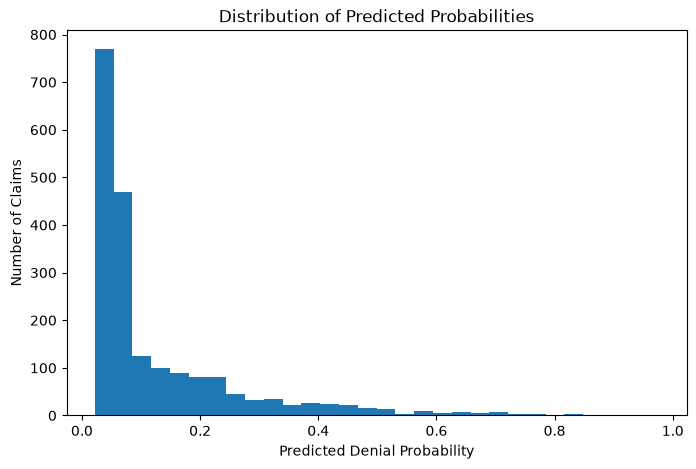

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(y_prob, bins=30)
plt.xlabel("Predicted Denial Probability")
plt.ylabel("Number of Claims")
plt.title("Distribution of Predicted Probabilities")
plt.show()

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.60, 0.05)

results = []

for t in thresholds:
    preds = (y_prob >= t).astype(int)

    results.append({
        "Threshold": round(t, 2),
        "Precision": round(precision_score(y_test, preds), 3),
        "Recall": round(recall_score(y_test, preds), 3),
        "F1 Score": round(f1_score(y_test, preds), 3)
    })

threshold_df = pd.DataFrame(results)

print(threshold_df)

   Threshold  Precision  Recall  F1 Score
0       0.10      0.267   0.729     0.391
1       0.15      0.304   0.649     0.414
2       0.20      0.353   0.558     0.432
3       0.25      0.404   0.450     0.426
4       0.30      0.431   0.371     0.398
5       0.35      0.458   0.303     0.365
6       0.40      0.488   0.247     0.328
7       0.45      0.545   0.191     0.283
8       0.50      0.540   0.135     0.217
9       0.55      0.583   0.112     0.187


In [8]:
X.head()

,payer_name,plan_type,provider_specialty,cpt_code,icd10_code,claim_amount,prior_auth_required,prior_auth_on_file,documentation_complete,eligibility_verified,provider_credentialed,coding_valid,duplicate_indicator,days_to_submit
0,Aetna Commercial,Commercial,Dermatology,70553,M17.11,729.58,1,1,1,1,1,1,0,12
1,BlueShield Commercial,Commercial,Dermatology,99214,M17.11,1119.21,0,1,1,1,1,1,0,6
2,Aetna Commercial,Commercial,Gastroenterology,93000,I10,2959.21,0,1,1,1,1,1,0,5
3,State Medicaid,Medicaid,Orthopedics,99214,I10,5848.79,1,1,1,1,1,1,0,7
4,Humana Medicare Advantage,Medicare Advantage,Orthopedics,71046,E11.9,5646.59,1,1,1,1,1,1,0,7


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
predictions = model.predict(X_test)

probabilities = model.predict_proba(X_test)[:, 1]

NameError: name 'model' is not defined

In [ ]:
print("Accuracy")

print(
    accuracy_score(
        y_test,
        predictions
    )
)

print()

print("ROC-AUC")

print(
    roc_auc_score(
        y_test,
        probabilities
    )
)

Accuracy
0.7495

ROC-AUC
0.782787660108565


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    RocCurveDisplay,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score
)

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, predictions):.3f}")

Accuracy: 0.750


In [ ]:
print(f"Precision: {precision_score(y_test, predictions):.3f}")

Precision: 0.290


In [ ]:
print(f"Recall: {recall_score(y_test, predictions):.3f}")

Recall: 0.685


In [ ]:
print(f"F1 Score: {f1_score(y_test, predictions):.3f}")

F1 Score: 0.407


In [ ]:
print(f"ROC AUC: {roc_auc_score(y_test, probabilities):.3f}")

ROC AUC: 0.783


In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.94      0.76      0.84      1749
           1       0.29      0.69      0.41       251

    accuracy                           0.75      2000
   macro avg       0.62      0.72      0.62      2000
weighted avg       0.86      0.75      0.79      2000



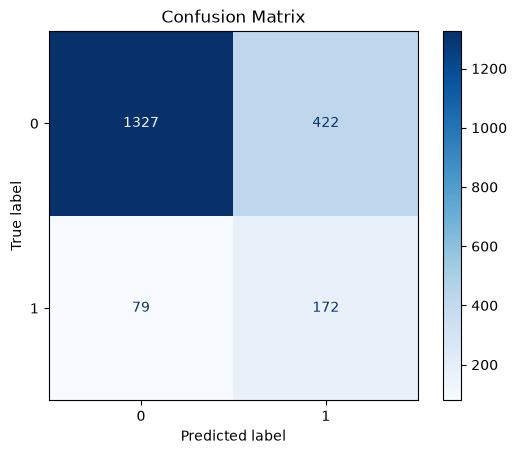

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

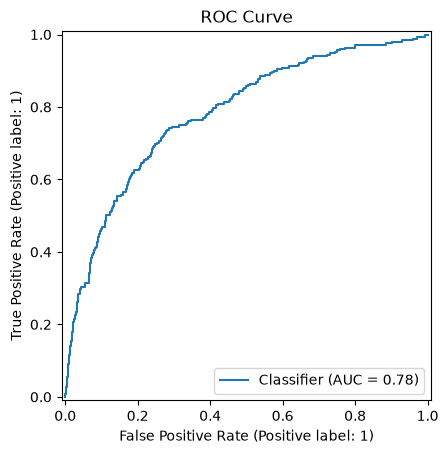

In [ ]:
RocCurveDisplay.from_predictions(
    y_test,
    probabilities
)

plt.title("ROC Curve")
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    "Absolute",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute
8,duplicate_indicator,2.350800,2.350800
3,prior_auth_on_file,-2.139054,2.139054
10,payer_name_Ambetter Marketplace,1.798307,1.798307
6,provider_credentialed,-1.494557,1.494557
4,documentation_complete,-1.471326,1.471326
7,coding_valid,-1.230110,1.230110
5,eligibility_verified,-1.172239,1.172239
14,plan_type_Commercial,1.086996,1.086996
15,plan_type_Medicaid,0.834826,0.834826
13,payer_name_State Medicaid,0.834826,0.834826


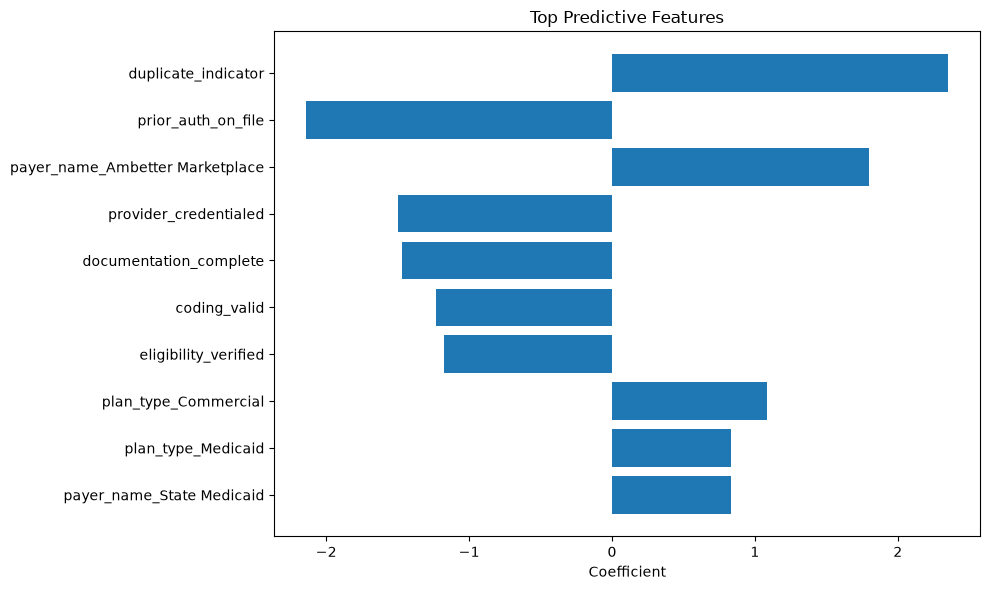

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Predictive Features")
plt.xlabel("Coefficient")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
MODEL_PATH = PROJECT_ROOT / "models" / "claim_denial_model.pkl"
FEATURE_COLUMNS_PATH = PROJECT_ROOT / "models" / "feature_columns.pkl"

joblib.dump(model, MODEL_PATH)
joblib.dump(X.columns.tolist(), FEATURE_COLUMNS_PATH)

print(f"Model saved to: {MODEL_PATH}")
print(f"Feature columns saved to: {FEATURE_COLUMNS_PATH}")

Model saved to: /Users/simmi/Downloads/healthcare-claim-denial-analytics/models/claim_denial_model.pkl
Feature columns saved to: /Users/simmi/Downloads/healthcare-claim-denial-analytics/models/feature_columns.pkl


In [ ]:
%pip install joblib


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import joblib

features = [
    "payer_name",
    "plan_type",
    "provider_specialty",
    "cpt_code",
    "icd10_code",
    "claim_amount",
    "prior_auth_required",
    "prior_auth_on_file",
    "documentation_complete",
    "eligibility_verified",
    "provider_credentialed",
    "coding_valid",
    "duplicate_indicator",
    "days_to_submit"
]

# Recreate raw input data here
X = claims[features].copy()
y = claims["was_denied"].copy()

print("Columns used for training:")
print(X.columns.tolist())

categorical_features = [
    "payer_name",
    "plan_type",
    "provider_specialty",
    "cpt_code",
    "icd10_code"
]

numeric_features = [
    "claim_amount",
    "prior_auth_required",
    "prior_auth_on_file",
    "documentation_complete",
    "eligibility_verified",
    "provider_credentialed",
    "coding_valid",
    "duplicate_indicator",
    "days_to_submit"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=10000,
                random_state=42
            )
        )
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model_pipeline.fit(X_train, y_train)

predictions = model_pipeline.predict(X_test)
probabilities = model_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, predictions))
print("ROC-AUC:", roc_auc_score(y_test, probabilities))

joblib.dump(
    model_pipeline,
    "../models/claim_denial_pipeline.pkl"
)

print("Pipeline saved successfully.")

Columns used for training:
['payer_name', 'plan_type', 'provider_specialty', 'cpt_code', 'icd10_code', 'claim_amount', 'prior_auth_required', 'prior_auth_on_file', 'documentation_complete', 'eligibility_verified', 'provider_credentialed', 'coding_valid', 'duplicate_indicator', 'days_to_submit']
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1749
           1       0.54      0.14      0.22       251

    accuracy                           0.88      2000
   macro avg       0.71      0.56      0.57      2000
weighted avg       0.84      0.88      0.84      2000

ROC-AUC: 0.7817238763641832
Pipeline saved successfully.
